# Importing Relevent Libraries

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries Imported")


Libraries Imported


# Fetching the historical stock data

In [2]:
# Define the list of ticker symbols
ticker_symbols = ['HINDUNILVR.NS', 'INFY.NS', 'ASIANPAINT.NS', 'HEROMOTOCO.NS']

# Set the start and end dates for the historical data
start_date = '2021-01-01'  
end_date = '2024-04-01'

# Fetch the stock data
def fetch_stock_data(tickers, start_date, end_date):
    data = yf.download(tickers, start=start_date, end=end_date)
    return data['Close']

# Get data
stock_data = fetch_stock_data(ticker_symbols, start_date, end_date)

[*********************100%%**********************]  4 of 4 completed


# Plotting the close price of the stocks

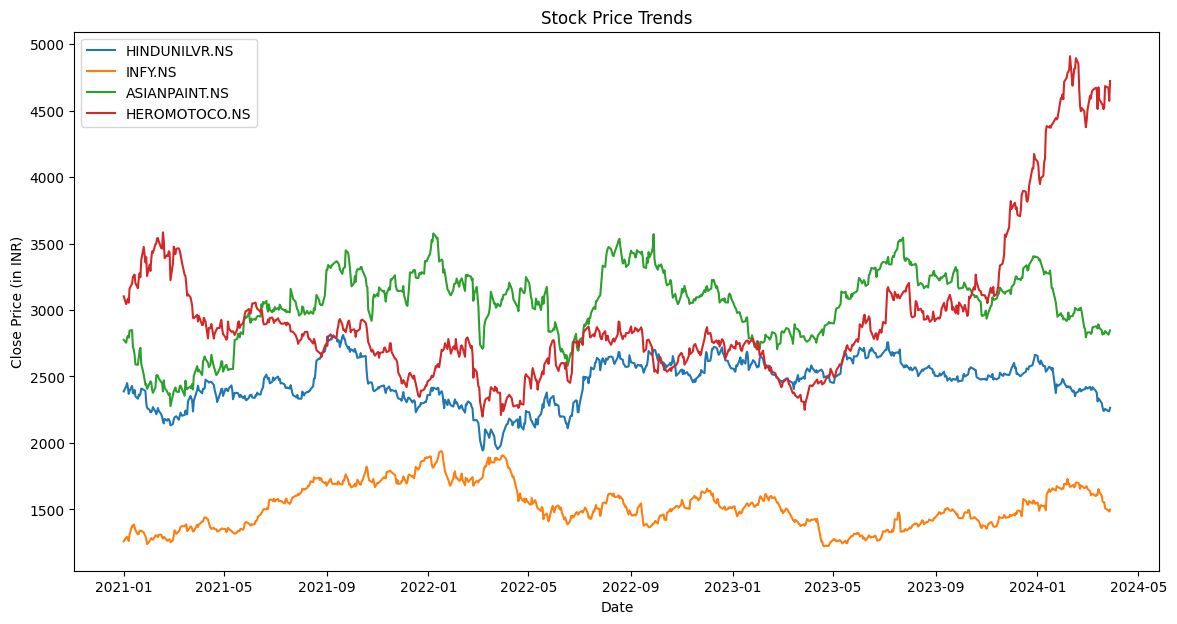

In [3]:
# Plotting the close price of the stocks
plt.figure(figsize=(14, 7))
for ticker in ticker_symbols:
    plt.plot(stock_data[ticker], label=ticker)
plt.title('Stock Price Trends')
plt.xlabel('Date')
plt.ylabel('Close Price (in INR)')
plt.legend()
plt.savefig('stock_price_trends_high_resolution.png', dpi=300, bbox_inches='tight')
plt.show()

# Display summary statistics

In [15]:
stock_data.describe()

Ticker,ASIANPAINT.NS,HEROMOTOCO.NS,HINDUNILVR.NS,INFY.NS
count,801.000000,801.000000,801.000000,801.000000
mean,3042.743694,2949.845380,2456.072288,1523.253373
std,267.502373,549.480497,169.342059,163.427570
min,2277.199951,2198.699951,1943.949951,1223.400024
25%,2864.550049,2641.449951,2348.949951,1393.550049
50%,3083.750000,2806.350098,2478.649902,1504.400024
75%,3240.699951,3038.000000,2579.600098,1653.300049
max,3576.300049,4908.850098,2812.449951,1939.500000


# Correlation matrix of stocks

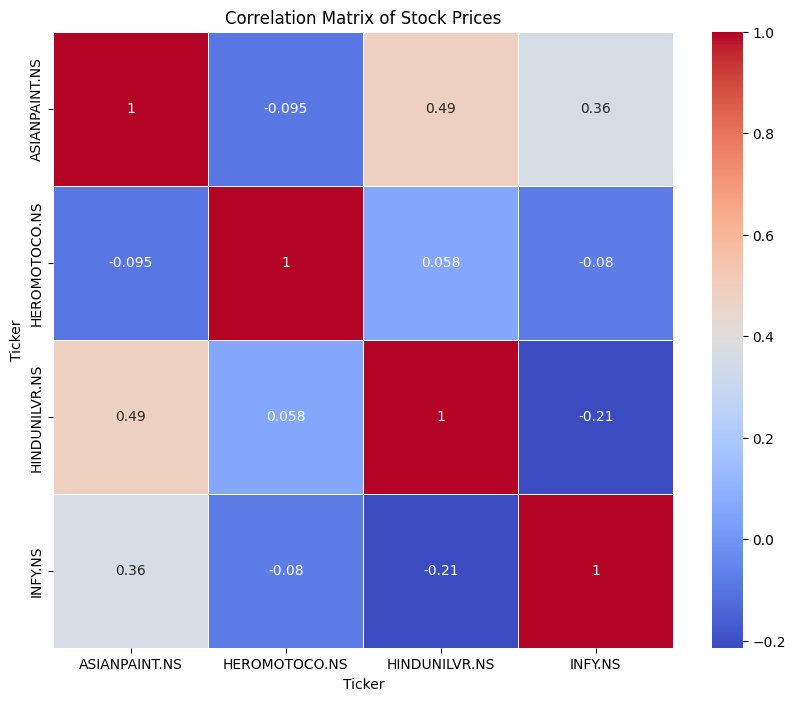

In [4]:
# Compute the correlation matrix
correlation_matrix = stock_data.corr()

# Create a figure
plt.figure(figsize=(10, 8))

# Create a heatmap of the correlation matrix
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)

# Set the title of the heatmap
plt.title('Correlation Matrix of Stock Prices')

# Save the figure in high resolution
plt.savefig('correlation_matrix_high_quality.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()


[*********************100%%**********************]  4 of 4 completed


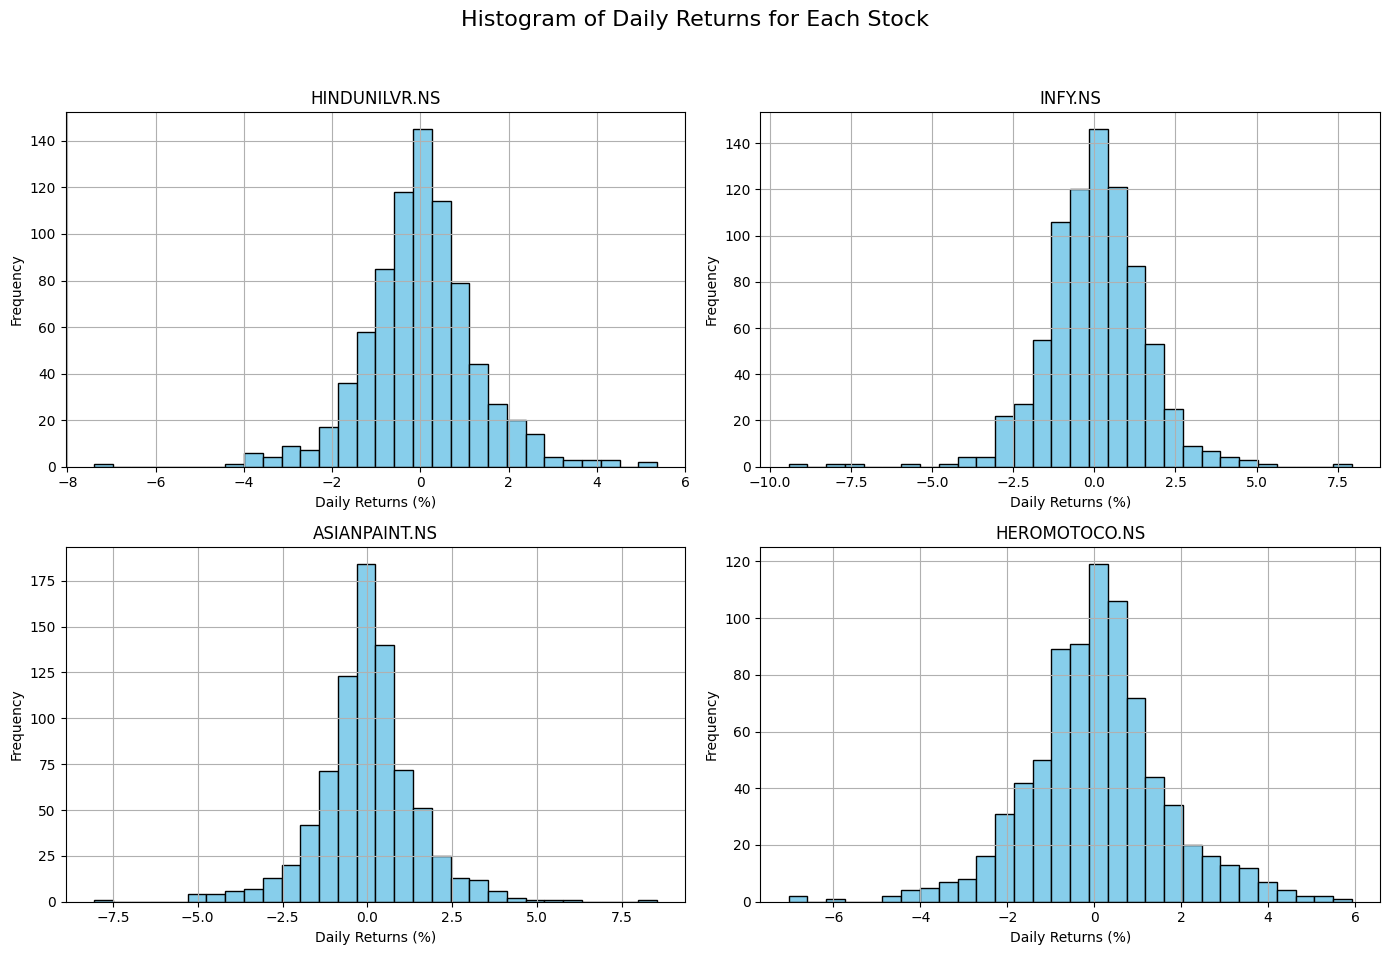

In [21]:
ticker_symbols = ['HINDUNILVR.NS', 'INFY.NS', 'ASIANPAINT.NS', 'HEROMOTOCO.NS']

# Set the start and end dates for the historical data
start_date = '2021-01-01'
end_date = '2024-04-01'

# Fetch the stock data
def fetch_stock_data(tickers, start_date, end_date):
    data = yf.download(tickers, start=start_date, end=end_date)
    return data['Adj Close']

# Get data
stock_data = fetch_stock_data(ticker_symbols, start_date, end_date)

# Calculate daily returns for each stock
daily_returns = stock_data.pct_change() * 100
daily_returns.dropna(inplace=True)  # Drop rows with NaN values

# Plot histograms for daily returns
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
fig.suptitle('Histogram of Daily Returns for Each Stock', fontsize=16)
axes = axes.flatten()  # Flatten to 1D array for easy iteration

for i, ticker in enumerate(ticker_symbols):
    axes[i].hist(daily_returns[ticker], bins=30, color='skyblue', edgecolor='black')
    axes[i].set_title(ticker)
    axes[i].set_xlabel('Daily Returns (%)')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust the layout to make room for the main title
plt.show()


# Relative Price Strength (RPS)

[*********************100%%**********************]  5 of 5 completed


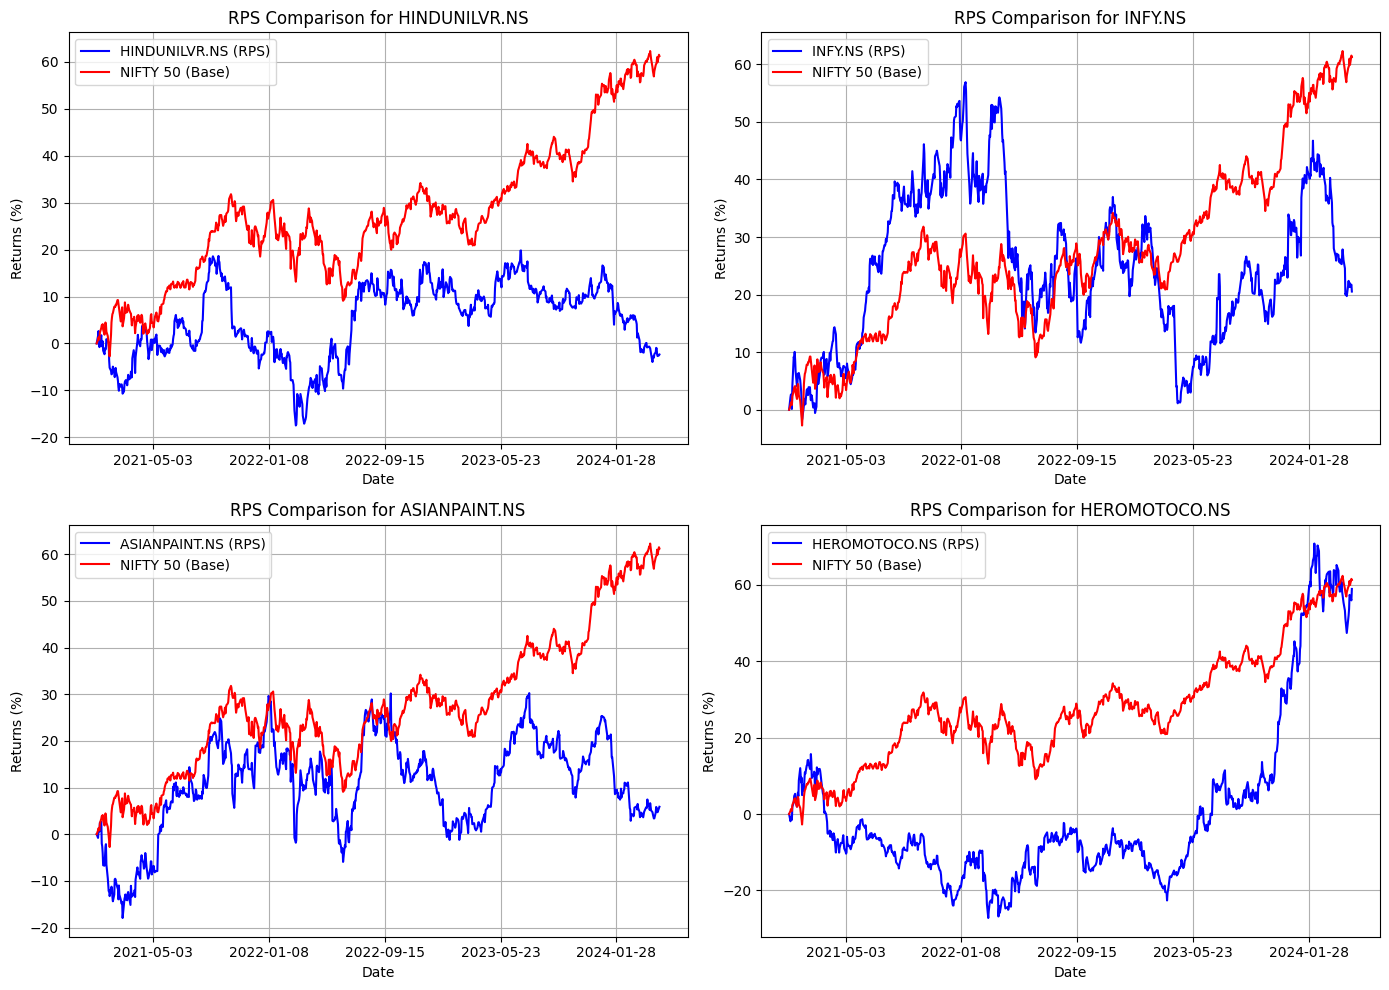

In [6]:
ticker_symbols = ['HINDUNILVR.NS', 'INFY.NS', 'ASIANPAINT.NS', 'HEROMOTOCO.NS']
benchmark_index = '^NSEI' 

# Set the start and end dates for the historical data
start_date = '2021-01-01'
end_date = '2024-05-01'

# Fetch the stock data
def fetch_stock_data(tickers, benchmark, start_date, end_date):
    tickers = tickers + [benchmark]
    data = yf.download(tickers, start=start_date, end=end_date)
    return data['Adj Close']

# Get data
stock_data = fetch_stock_data(ticker_symbols, benchmark_index, start_date, end_date)

# Calculate the percentage returns from the base price for each stock and the benchmark
percentage_returns = (stock_data.div(stock_data.iloc[0]) - 1) * 100

# Plotting the Relative Price Strength
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()  # Flatten to 1D array for easy iteration

for i, ticker in enumerate(ticker_symbols):
    axes[i].plot(percentage_returns.index, percentage_returns[ticker], label=f'{ticker} (RPS)', color='blue')
    axes[i].plot(percentage_returns.index, percentage_returns[benchmark_index], label='NIFTY 50 (Base)', color='red')
    axes[i].set_title(f'RPS Comparison for {ticker}')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Returns (%)')
    axes[i].legend()
    axes[i].xaxis.set_major_locator(plt.MaxNLocator(6))  # Limit number of x-ticks
    axes[i].grid(True)

plt.tight_layout()
# Save the figure in high resolution
plt.savefig('relative_price_strength_comparison_high_quality.png', dpi=400, bbox_inches='tight')
plt.show()


[*********************100%%**********************]  4 of 4 completed


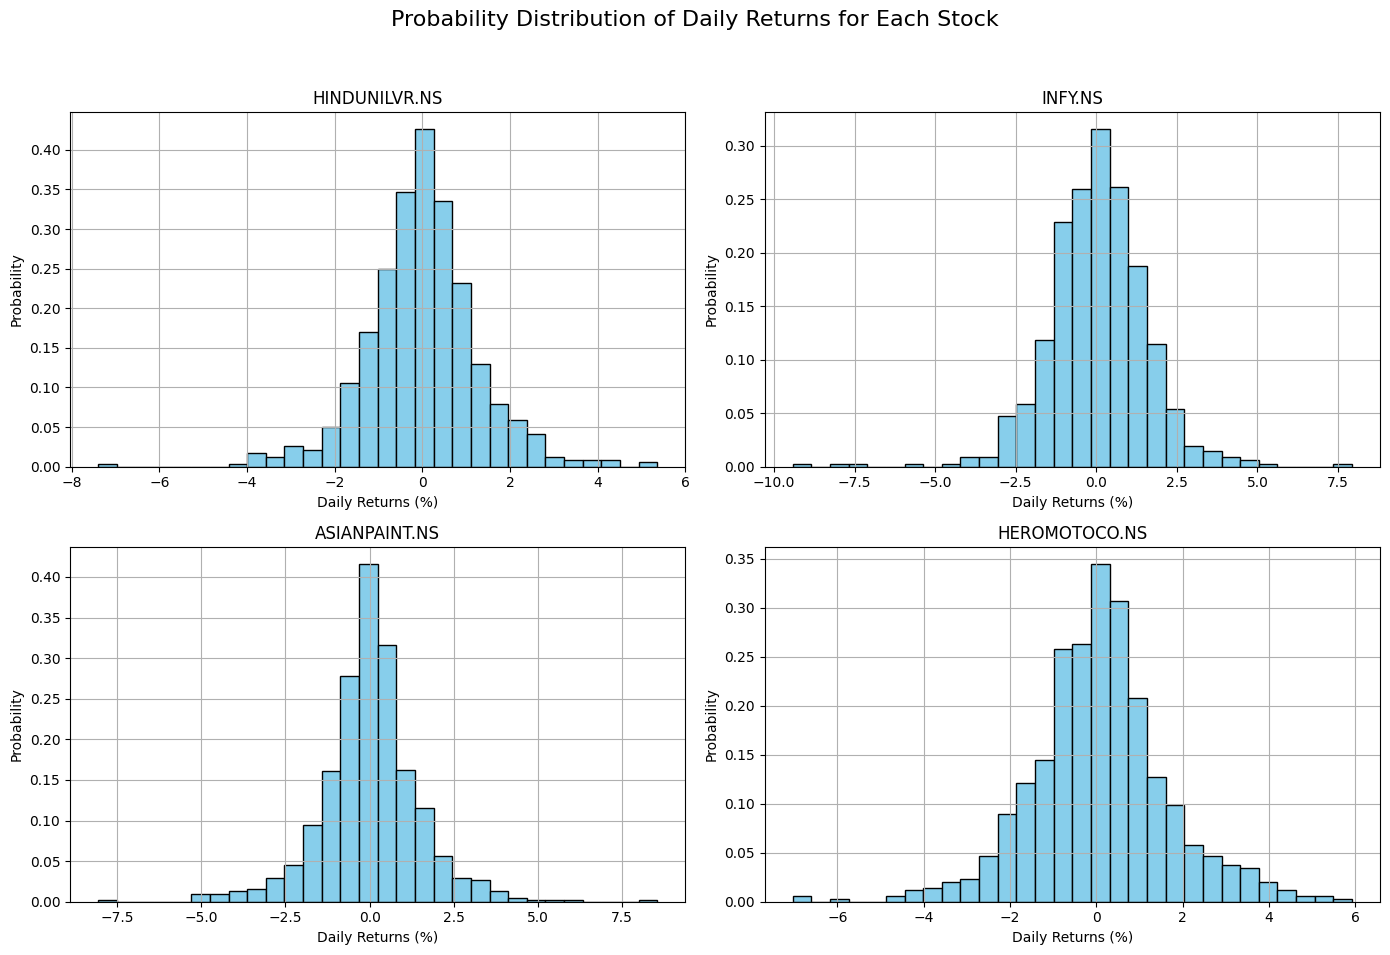

In [7]:
# Define the list of ticker symbols
ticker_symbols = ['HINDUNILVR.NS', 'INFY.NS', 'ASIANPAINT.NS', 'HEROMOTOCO.NS']

# Set the start and end dates for the historical data
start_date = '2021-01-01'
end_date = '2024-04-01'

# Fetch the stock data
def fetch_stock_data(tickers, start_date, end_date):
    data = yf.download(tickers, start=start_date, end=end_date)
    return data['Adj Close']

# Get data
stock_data = fetch_stock_data(ticker_symbols, start_date, end_date)

# Calculate daily returns for each stock
daily_returns = stock_data.pct_change() * 100
daily_returns.dropna(inplace=True)  # Drop rows with NaN values

# Plot histograms for daily returns
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
fig.suptitle('Probability Distribution of Daily Returns for Each Stock', fontsize=16)
axes = axes.flatten()  # Flatten to 1D array for easy iteration

for i, ticker in enumerate(ticker_symbols):
    axes[i].hist(daily_returns[ticker], bins=30, color='skyblue', edgecolor='black', density=True)
    axes[i].set_title(ticker)
    axes[i].set_xlabel('Daily Returns (%)')
    axes[i].set_ylabel('Probability')
    axes[i].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('daily_returns_histograms_high_quality.png', dpi=400, bbox_inches='tight')
plt.show()